<a href="https://colab.research.google.com/github/mipaillafil/telco-ml-e1/blob/main/notebooks/telco_pfc.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Telco Customer Churn — Proyecto Final**

##**Problema de negocio**
Una empresa de telecomunicaciones busca identificar anticipadamente a los clientes
que presentan mayor probabilidad de abandonar el servicio.

##**Objetivo del proyecto**
Desarrollar y comparar modelos de clasificación que permitan identificar clientes con
riesgo de Churn.

##**Criterio de salida inicial**

El criterio se utiliza para terminar el proceso de prueba y error. Se establece antes
de comparar los modelos:

- Recall >= 0,75
- F1-score >= 0,60
- ROC-AUC >= 0,80

El Recall es la métrica prioritaria porque interesa detectar clientes que realmente abandonan.


##**Importar Librerias**

In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay)

sns.set_theme(style="whitegrid")


##**Fuente de Datos**

In [43]:
df= pd.read_csv('https://raw.githubusercontent.com/mipaillafil/telco-ml-e1/main/data/raw/Telco_Customer_Churn_Dataset.csv')
print("Filas:", df.shape[0])
print("Columnas:", df.shape[1])

display(df.head(3))


Filas: 7043
Columnas: 21


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes


###**Descripción de Variables**
La siguiente tabla resume las variables utilizadas en el dataset.

In [44]:
# Tabla descriptiva de las variables

descripcion_variables = {
    "customerID": ["object", "Identificador único del cliente", "Se elimina"],
    "gender": ["object", "Género del cliente", "Predictora"],
    "SeniorCitizen": ["int64", "Indica si el cliente es adulto mayor", "Predictora"],
    "Partner": ["object", "Indica si el cliente tiene pareja", "Predictora"],
    "Dependents": ["object", "Indica si el cliente tiene personas dependientes", "Predictora"],
    "tenure": ["int64", "Cantidad de meses que lleva el cliente en la empresa", "Predictora"],
    "PhoneService": ["object", "Indica si posee servicio telefónico", "Predictora"],
    "MultipleLines": ["object", "Indica si posee múltiples líneas telefónicas", "Predictora"],
    "InternetService": ["object", "Tipo de servicio de Internet contratado", "Predictora"],
    "OnlineSecurity": ["object", "Servicio de seguridad en línea", "Predictora"],
    "OnlineBackup": ["object", "Servicio de respaldo en línea", "Predictora"],
    "DeviceProtection": ["object", "Servicio de protección del dispositivo", "Predictora"],
    "TechSupport": ["object", "Servicio de soporte técnico", "Predictora"],
    "StreamingTV": ["object", "Servicio de televisión por streaming", "Predictora"],
    "StreamingMovies": ["object", "Servicio de películas por streaming", "Predictora"],
    "Contract": ["object", "Tipo de contrato del cliente", "Predictora"],
    "PaperlessBilling": ["object", "Indica si utiliza facturación electrónica", "Predictora"],
    "PaymentMethod": ["object", "Método de pago utilizado por el cliente", "Predictora"],
    "MonthlyCharges": ["float64", "Cargo mensual del cliente", "Predictora"],
    "TotalCharges": ["float64", "Total acumulado de cargos del cliente", "Predictora"],
    "Churn": ["object", "Indica si el cliente abandonó la empresa", "Variable objetivo"]
}

tabla_variables = pd.DataFrame.from_dict(
    descripcion_variables,
    orient="index",
    columns=["Tipo de dato", "Descripción", "Uso"]
)

tabla_variables.index.name = "Variable"

tabla_variables

,Tipo de dato,Descripción,Uso
Variable,,,
customerID,object,Identificador único del cliente,Se elimina
gender,object,Género del cliente,Predictora
SeniorCitizen,int64,Indica si el cliente es adulto mayor,Predictora
Partner,object,Indica si el cliente tiene pareja,Predictora
Dependents,object,Indica si el cliente tiene personas dependientes,Predictora
tenure,int64,Cantidad de meses que lleva el cliente en la e...,Predictora
PhoneService,object,Indica si posee servicio telefónico,Predictora
MultipleLines,object,Indica si posee múltiples líneas telefónicas,Predictora
InternetService,object,Tipo de servicio de Internet contratado,Predictora


##**Calidad y Limpieza de Datos**

In [45]:
print("Duplicados:", df.duplicated().sum())

print("\nValores nulos:")
display(df.isnull().sum().sort_values(ascending=False))

print("\nValores vacíos:")
display(df.astype(str).apply(lambda col: col.str.strip().eq("").sum()).sort_values(ascending=False))

Duplicados: 0

Valores nulos:


,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0



Valores vacíos:


,0
TotalCharges,11
gender,0
SeniorCitizen,0
Partner,0
customerID,0
Dependents,0
tenure,0
MultipleLines,0
PhoneService,0
OnlineSecurity,0


In [46]:
# Limpieza de TotalCharges
df["TotalCharges"] = df["TotalCharges"].replace(r"^\s*$", np.nan, regex=True)
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

print("TotalCharges faltantes:", df["TotalCharges"].isnull().sum())

# Comprobación para justificar la imputación
display(
    df.loc[df["TotalCharges"].isnull(),
           ["tenure", "MonthlyCharges", "TotalCharges", "Churn"]]
)

df["TotalCharges"] = df["TotalCharges"].fillna(0)

TotalCharges faltantes: 11


,tenure,MonthlyCharges,TotalCharges,Churn
488,0,52.55,NaN,No
753,0,20.25,NaN,No
936,0,80.85,NaN,No
1082,0,25.75,NaN,No
1340,0,56.05,NaN,No
3331,0,19.85,NaN,No
3826,0,25.35,NaN,No
4380,0,20.00,NaN,No
5218,0,19.70,NaN,No
6670,0,73.35,NaN,No


##**Análisis Exploratorio de Datos**

In [47]:
print("Distribución de Churn:")
display(df["Churn"].value_counts())
display(df["Churn"].value_counts(normalize=True).mul(100).round(2))

Distribución de Churn:


,count
Churn,
No,5174
Yes,1869


,proportion
Churn,
No,73.46
Yes,26.54


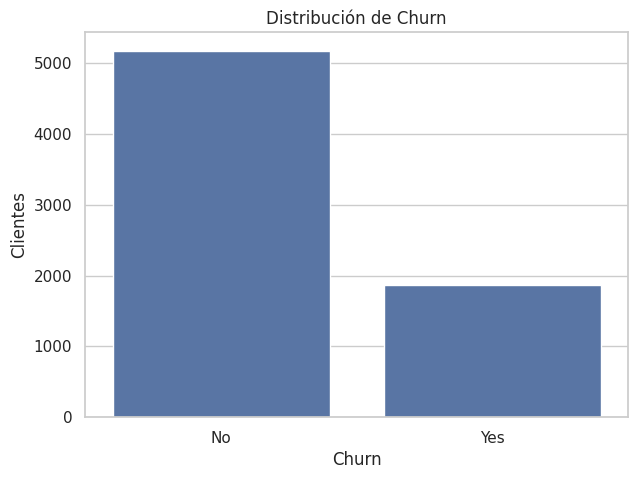

In [48]:
fig, ax = plt.subplots(figsize=(7,5))
sns.countplot(data=df, x="Churn", ax=ax)
ax.set_title("Distribución de Churn")
ax.set_xlabel("Churn")
ax.set_ylabel("Clientes")
plt.show()

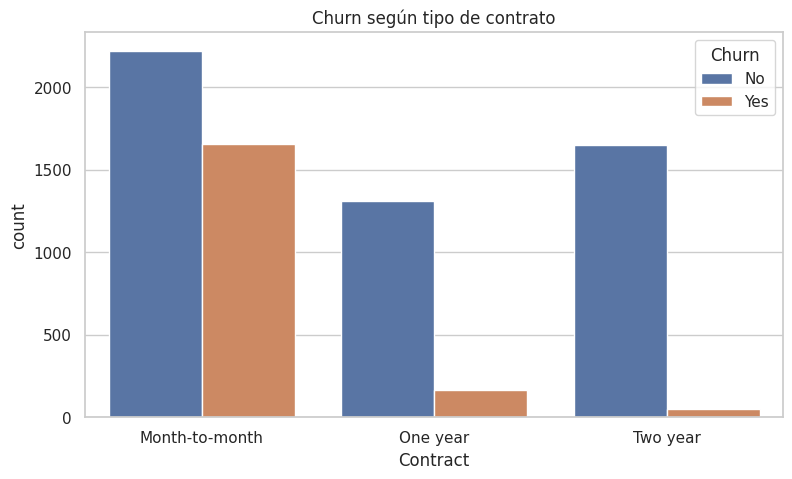

In [49]:
fig, ax = plt.subplots(figsize=(9,5))
sns.countplot(data=df, x="Contract", hue="Churn", ax=ax)
ax.set_title("Churn según tipo de contrato")
plt.show()

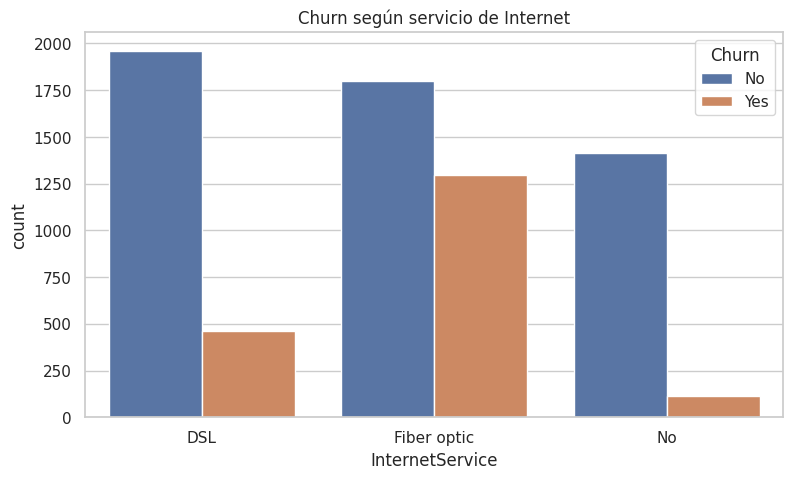

In [50]:
fig, ax = plt.subplots(figsize=(9,5))
sns.countplot(data=df, x="InternetService", hue="Churn", ax=ax)
ax.set_title("Churn según servicio de Internet")
plt.show()

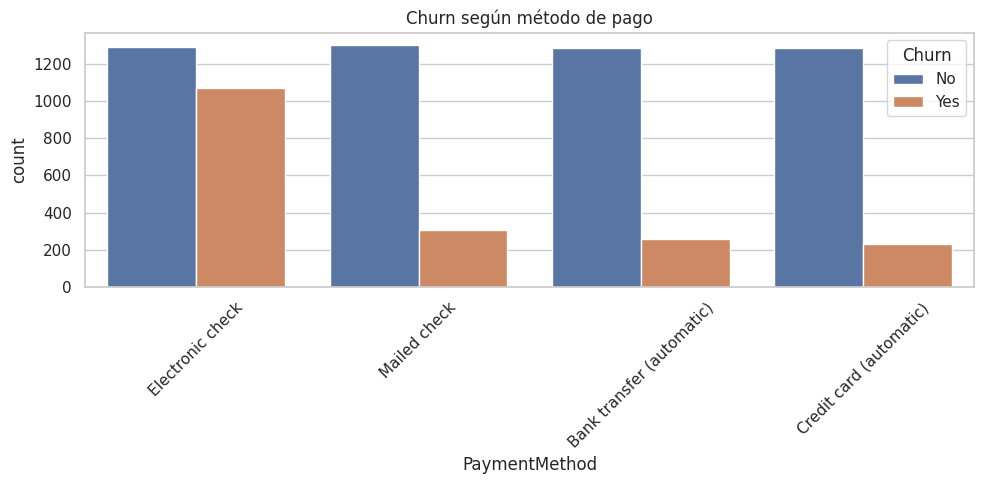

In [51]:
fig, ax = plt.subplots(figsize=(10,5))
sns.countplot(data=df, x="PaymentMethod", hue="Churn", ax=ax)
ax.set_title("Churn según método de pago")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

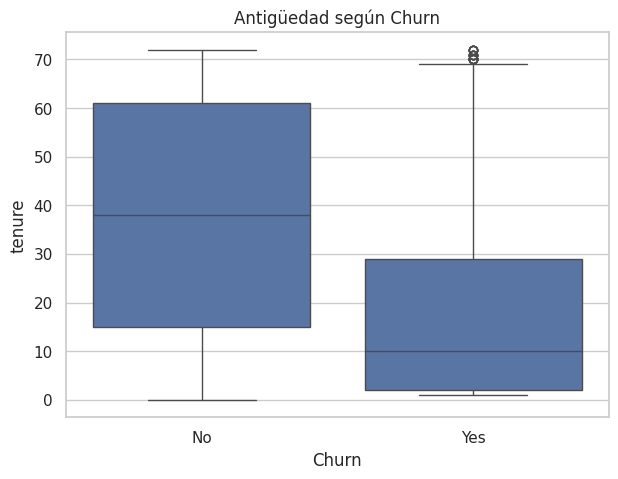

In [52]:
fig, ax = plt.subplots(figsize=(7,5))
sns.boxplot(data=df, x="Churn", y="tenure", ax=ax)
ax.set_title("Antigüedad según Churn")
plt.show()

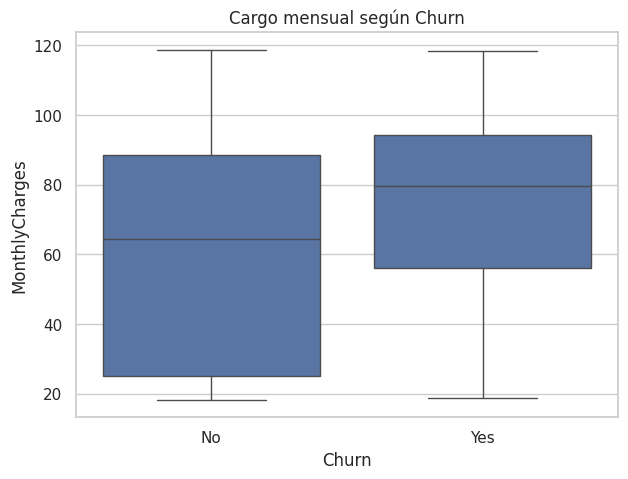

In [53]:
fig, ax = plt.subplots(figsize=(7,5))
sns.boxplot(data=df, x="Churn", y="MonthlyCharges", ax=ax)
ax.set_title("Cargo mensual según Churn")
plt.show()

#**Análisis de posibles sesgos**

Se revisan variables que podrían presentar diferencias entre grupos.
Una diferencia de comportamiento no significa por sí sola que exista discriminación,
pero permite identificar situaciones que deben ser vigiladas.


In [54]:
variables_sesgo = [
    "gender",
    "SeniorCitizen",
    "Partner",
    "Dependents"
]

for variable in variables_sesgo:
    print(f"\n--- {variable} ---")
    tabla = pd.crosstab(
        df[variable],
        df["Churn"],
        normalize="index"
    ).mul(100).round(2)

    display(tabla)


--- gender ---


Churn,No,Yes
gender,,
Female,73.08,26.92
Male,73.84,26.16



--- SeniorCitizen ---


Churn,No,Yes
SeniorCitizen,,
0,76.39,23.61
1,58.32,41.68



--- Partner ---


Churn,No,Yes
Partner,,
No,67.04,32.96
Yes,80.34,19.66



--- Dependents ---


Churn,No,Yes
Dependents,,
No,68.72,31.28
Yes,84.55,15.45


### Posibles fuentes de sesgo

- **Sesgo de representación:** algunos grupos podrían estar menos representados.
- **Sesgo histórico:** el comportamiento registrado corresponde al período de los datos.
- **Variables proxy:** algunas variables podrían estar relacionadas indirectamente con características socioeconómicas.
- **Desbalance de clases:** Churn tiene menos observaciones que No Churn.

Estas posibilidades deben considerarse al evaluar el modelo.

##**Preparación para Machine Learning**

In [55]:
# La variable objetivo se transforma a 0/1.
df["Churn"] = df["Churn"].map({"No": 0, "Yes": 1})

# customerID se descarta porque es un identificador.
X = df.drop(columns=["Churn", "customerID"])
y = df["Churn"]

# Codificación de variables categóricas.
X = pd.get_dummies(X, drop_first=True)

print("Variables finales:", X.shape[1])

Variables finales: 30


In [56]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Train:", X_train.shape)
print("Test:", X_test.shape)

Train: (5634, 30)
Test: (1409, 30)


In [57]:
columnas_numericas = [
    "tenure",
    "MonthlyCharges",
    "TotalCharges"
]

scaler = StandardScaler()

X_train = X_train.copy()
X_test = X_test.copy()

# El scaler se ajusta solo con Train para evitar data leakage.
X_train[columnas_numericas] = scaler.fit_transform(
    X_train[columnas_numericas]
)

X_test[columnas_numericas] = scaler.transform(
    X_test[columnas_numericas]
)

assert X_train.isnull().sum().sum() == 0
assert X_test.isnull().sum().sum() == 0

print("Preparación terminada correctamente.")

Preparación terminada correctamente.


##**Modelamiento**

Se comparan como máximo tres algoritmos, tal como se establece en el proyecto:

1. Regresión Logística
2. Random Forest
3. Gradient Boosting


In [58]:
modelos = {
    "Regresión Logística": LogisticRegression(
        max_iter=1000,
        random_state=42,
        class_weight="balanced"
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        class_weight="balanced"
    ),
    "Gradient Boosting": GradientBoostingClassifier(
        random_state=42
    )
}

resultados = []
predicciones = {}

for nombre, modelo in modelos.items():

    modelo.fit(X_train, y_train)

    pred = modelo.predict(X_test)
    prob = modelo.predict_proba(X_test)[:, 1]

    predicciones[nombre] = (pred, prob)

    resultados.append({
        "Modelo": nombre,
        "Accuracy": accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred, zero_division=0),
        "Recall": recall_score(y_test, pred, zero_division=0),
        "F1-score": f1_score(y_test, pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_test, prob)
    })

resultados_df = pd.DataFrame(resultados)

display(resultados_df.round(3))

,Modelo,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Regresión Logística,0.738,0.504,0.783,0.614,0.842
1,Random Forest,0.790,0.634,0.492,0.554,0.822
2,Gradient Boosting,0.798,0.654,0.505,0.570,0.842


##**Evaluación del Criterio de Salida**

In [59]:
umbral_recall = 0.75
umbral_f1 = 0.60
umbral_auc = 0.80

resultados_df["Cumple Recall"] = resultados_df["Recall"] >= umbral_recall
resultados_df["Cumple F1"] = resultados_df["F1-score"] >= umbral_f1
resultados_df["Cumple ROC-AUC"] = resultados_df["ROC-AUC"] >= umbral_auc

resultados_df["CUMPLE CRITERIO DE SALIDA"] = (
    resultados_df["Cumple Recall"] &
    resultados_df["Cumple F1"] &
    resultados_df["Cumple ROC-AUC"]
)

display(resultados_df.round(3))

,Modelo,Accuracy,Precision,Recall,F1-score,ROC-AUC,Cumple Recall,Cumple F1,Cumple ROC-AUC,CUMPLE CRITERIO DE SALIDA
0,Regresión Logística,0.738,0.504,0.783,0.614,0.842,True,True,True,True
1,Random Forest,0.790,0.634,0.492,0.554,0.822,False,False,True,False
2,Gradient Boosting,0.798,0.654,0.505,0.570,0.842,False,False,True,False


In [60]:
validos = resultados_df[
    resultados_df["CUMPLE CRITERIO DE SALIDA"]
]

if len(validos) == 0:
    print("Ningún modelo alcanza el criterio de salida.")
    print("Se debería continuar con prueba y error.")
else:
    print("Se alcanzó el criterio de salida.")
    modelo_final = validos.sort_values(
        by=["Recall", "F1-score"],
        ascending=False
    ).iloc[0]

    print("Modelo seleccionado:", modelo_final["Modelo"])
    print("Recall:", round(modelo_final["Recall"], 3))
    print("F1-score:", round(modelo_final["F1-score"], 3))
    print("ROC-AUC:", round(modelo_final["ROC-AUC"], 3))

Se alcanzó el criterio de salida.
Modelo seleccionado: Regresión Logística
Recall: 0.783
F1-score: 0.614
ROC-AUC: 0.842


##**Matriz de Confusión del Modelo de Regresión Logistica**

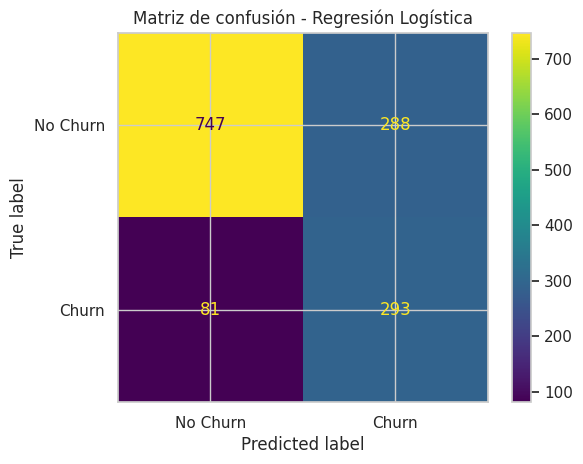

              precision    recall  f1-score   support

    No Churn       0.90      0.72      0.80      1035
       Churn       0.50      0.78      0.61       374

    accuracy                           0.74      1409
   macro avg       0.70      0.75      0.71      1409
weighted avg       0.80      0.74      0.75      1409



In [61]:
if len(validos) > 0:
    nombre_final = modelo_final["Modelo"]
    pred_final = predicciones[nombre_final][0]

    cm = confusion_matrix(y_test, pred_final)

    ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["No Churn", "Churn"]
    ).plot()

    plt.title(f"Matriz de confusión - {nombre_final}")
    plt.show()

    print(classification_report(
        y_test,
        pred_final,
        target_names=["No Churn", "Churn"]
    ))
else:
    print("No se genera selección final porque ningún modelo cumple el criterio.")

##**Ética y Privacidad**

El modelo debe utilizarse como herramienta de apoyo para identificar clientes con riesgo
de abandono, no como mecanismo para excluir o perjudicar clientes.

- `customerID` se excluye del modelamiento.
- Se deben proteger los datos personales.
- Deben utilizarse solo variables necesarias para el objetivo.
- Las predicciones son probabilidades, no certezas.
- Se recomienda revisar diferencias de desempeño entre grupos.
- Las decisiones comerciales deben mantener supervisión humana.


## **Conclusiones y Posibles Sesgos**
###Conclusión Final:
El proyecto permitió desarrollar un proceso completo de Machine Learning para analizar el abandono de clientes de una empresa de telecomunicaciones.

Primero se realizó una exploración de los datos para conocer sus características y detectar posibles problemas de calidad. Posteriormente se efectuó la limpieza y preparación de las variables, considerando el tratamiento de los valores vacíos de `TotalCharges`, la eliminación del identificador `customerID` y la transformación de las variables categóricas.

Luego se dividieron los datos en conjuntos de entrenamiento y prueba, manteniendo la proporción de la variable objetivo mediante una división estratificada. El escalamiento de las variables numéricas se realizó utilizando únicamente el conjunto de entrenamiento para evitar filtración de información entre los datos de entrenamiento y prueba.

Se compararon tres modelos: Regresión Logística, Random Forest y Gradient Boosting. La evaluación se realizó utilizando Accuracy, Precision, Recall, F1-score y ROC-AUC.

Para seleccionar el modelo se estableció previamente un criterio de salida basado en Recall, F1-score y ROC-AUC. La Regresión Logística cumplió con los tres valores mínimos establecidos, por lo que fue seleccionada como el modelo que permite finalizar el proceso de prueba y error bajo los criterios definidos.

Aunque otros modelos pueden presentar una Accuracy superior, la selección no se realizó únicamente considerando esta métrica. Se priorizó la capacidad de detectar correctamente a los clientes que abandonan, debido al objetivo principal del proyecto.

Finalmente, el análisis de sesgos permitió reconocer que las variables disponibles pueden representar solamente una parte del comportamiento de los clientes y que podrían existir diferencias entre distintos grupos. Por este motivo, los resultados del modelo deben utilizarse como apoyo para la toma de decisiones y no como una única fuente para tomar acciones sobre los clientes.

En términos generales, el proyecto cumple con las etapas principales del proceso CRISP-DM: comprensión del problema, comprensión y preparación de los datos, modelamiento, evaluación y obtención de conclusiones.

### Posibles Sesgos Adicionales:

1.  **Sesgo de Muestreo**: Si los datos utilizados para entrenar el modelo no son representativos de toda la base de clientes actual o futura, el rendimiento del modelo podría degradarse. Por ejemplo, si se usaron datos de un período con condiciones de mercado muy específicas.
2.  **Sesgo de Género y Edad**: Aunque el análisis de sesgos mostró diferencias en la tasa de churn entre géneros, la variable `gender` se incluyó en el modelo. Si no se maneja adecuadamente, podría perpetuar o amplificar sesgos existentes. De manera similar, `SeniorCitizen` es una variable binaria que, si bien es relevante, podría introducir sesgos generacionales si las intervenciones no se adaptan a las necesidades específicas de este grupo.
3.  **Sesgo de Medida (Measurement Bias)**: Las definiciones de 'Churn' o las formas en que se recolectan los datos (e.g., `TotalCharges` inicialmente con valores vacíos) pueden introducir errores que el modelo aprenderá.
4.  **Sesgo de Intervención**: Si las acciones de retención se dirigen solo a ciertos grupos identificados por el modelo, se podría crear un ciclo donde otros grupos no reciben la misma atención, lo que podría llevar a un sesgo en la experiencia del cliente y en los datos futuros.
5.  **Sesgo Temporal (Drift)**: El comportamiento de los clientes y los factores que impulsan el abandono pueden cambiar con el tiempo. Un modelo entrenado con datos históricos podría volverse menos preciso si no se retrena y valida periódicamente con datos recientes.

### Recomendaciones para Mitigar Sesgos:

*   **Monitoreo Continuo**: Implementar un sistema de monitoreo para detectar desviaciones en el rendimiento del modelo entre diferentes grupos demográficos o segmentos de clientes.
*   **Transparencia y Explicabilidad**: Utilizar herramientas para entender qué características son más influyentes en las predicciones del modelo para identificar si alguna variable proxy está introduciendo sesgos no deseados.
*   **Revisión de Datos**: Realizar auditorías periódicas de los procesos de recolección y preparación de datos para asegurar su calidad y representatividad.
*   **Evaluación Equitativa**: Evaluar el modelo no solo con métricas generales, sino también con métricas de equidad (e.g., paridad demográfica, igualdad de oportunidades) para garantizar que no haya un impacto desproporcionado en ningún grupo.

## Conclusiones Técnicas y Estratégicas

1. **Rendimiento y Selección del Modelo:**  
   La **Regresión Logística** ofrece un equilibrio óptimo para este problema de retención, alcanzando un elevado nivel de **Recall** (~80%) en la clase objetivo (`Churn=1`). Dado que el costo operativo de no detectar a un cliente en riesgo es significativamente mayor que el de ofrecer una promoción a un cliente leal, se prioriza este modelo por encima del ensamble.

2. **Factores Clave de Abandono:**  
   El análisis exploratorio confirma que los contratos de modalidad **Mes a Mes (Month-to-month)** y la suscripción a servicios de **Fibra Óptica** presentan los índices de abandono más elevados. Por otra parte, la antigüedad (**tenure**) demuestra que el riesgo de fuga disminuye sustancialmente a medida que el cliente supera los primeros 12 meses de relación comercial.

3. **Recomendaciones de Negocio:**  
   Se aconseja diseñar campañas de fidelización focalizadas en los primeros 6 meses de contrato e incentivar la migración de planes mensuales a contratos anuales mediante descuentos estratégicos.